In [115]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
from astropy.cosmology import Planck18
import matplotlib.pyplot as plt
import sys
import os

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))


In [116]:
nsa_cat = Table.read("/pscratch/sd/v/virajvm/catalog/nsa_v1_0_1.fits")


In [117]:
# ELPETRO_FLUX	float32[7]	nanomaggies	Elliptical SDSS-style Petrosian flux in GALEX/SDSS FNugriz (using r-band aperture)
# nsa_cat_f = nsa_cat["RA","DEC","Z", "ELPETRO_FLUX","SRC", "IN"]

In [118]:
# nsa_cat_f = nsa_cat[nsa_cat["ZSRC"] == "sdss"]

In [119]:
gfluxs = nsa_cat["ELPETRO_FLUX"].data.data[:,3]
rfluxs = nsa_cat["ELPETRO_FLUX"].data.data[:,4]


In [120]:
gmag = 22.5-2.5*np.log10(gfluxs)
rmag = 22.5-2.5*np.log10(rfluxs)


/tmp/ipykernel_105340/1121682628.py:1: RuntimeWarning: divide by zero encountered in log10
  gmag = 22.5-2.5*np.log10(gfluxs)
/tmp/ipykernel_105340/1121682628.py:1: RuntimeWarning: invalid value encountered in log10
  gmag = 22.5-2.5*np.log10(gfluxs)
/tmp/ipykernel_105340/1121682628.py:2: RuntimeWarning: divide by zero encountered in log10
  rmag = 22.5-2.5*np.log10(rfluxs)
/tmp/ipykernel_105340/1121682628.py:2: RuntimeWarning: invalid value encountered in log10
  rmag = 22.5-2.5*np.log10(rfluxs)


In [121]:
mask = (rmag < 17.8)

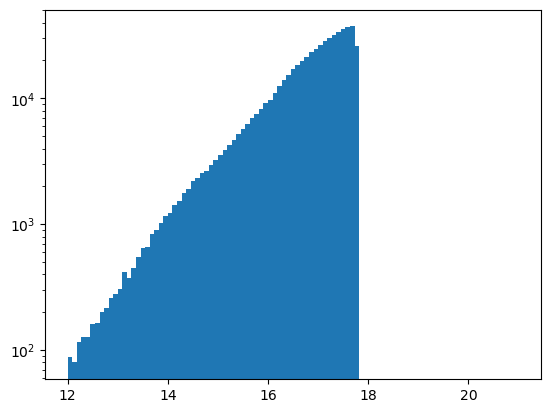

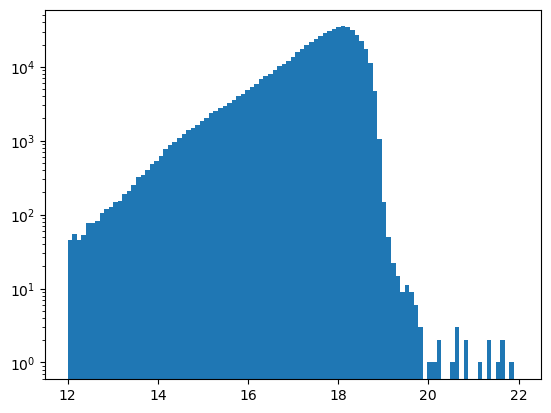

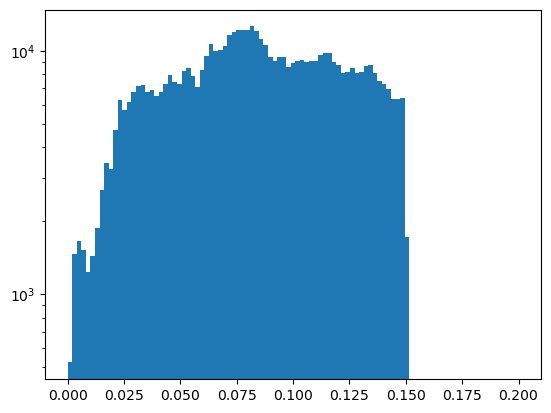

In [122]:
plt.hist(rmag[mask],bins=np.linspace(12,21,100))
plt.yscale("log")
plt.show()

plt.hist(gmag[mask],bins=np.linspace(12,22,100))
plt.yscale("log")
plt.show()

plt.hist(nsa_cat["Z"][mask],bins=np.linspace(0,0.2,100))
plt.yscale("log")
plt.show()

In [123]:
rmag_f = rmag[mask]
gmag_f = gmag[mask]


zred_f = nsa_cat["Z"].data[mask]

ra_f = nsa_cat["RA"].data[mask]
dec_f = nsa_cat["DEC"].data[mask]



In [124]:
# print(np.sum(rmag < 17.8))
# print(np.sum(rmag < 22))

In [125]:
gr_col = gmag_f - rmag_f

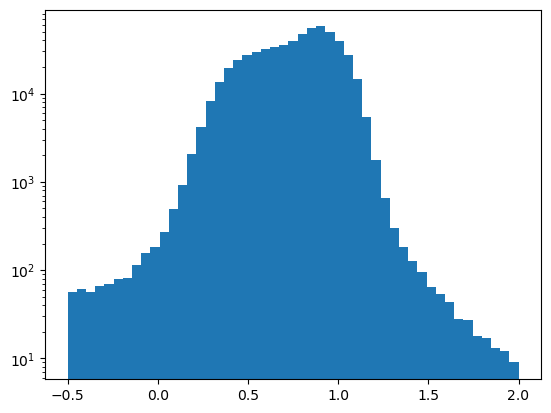

In [126]:

plt.hist(gr_col,bins=np.linspace(-0.5,2,50))
plt.yscale("log")
plt.show()


In [127]:
from desi_lowz_funcs import get_stellar_mass_mia

In [128]:
mstar_vals = get_stellar_mass_mia(gr_col, gmag_f, zred_f)

/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:577: RuntimeWarning: invalid value encountered in add
  kg =  (coeff_10 + coeff_11 + coeff_12 + coeff_13) + (coeff_20 + coeff_21 + coeff_22 + coeff_23) + (coeff_30 + coeff_31 + coeff_32) + (coeff_40 + coeff_41) + (coeff_50)
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:635: RuntimeWarning: divide by zero encountered in log10
  Mg = gmag + 5 - 5*np.log10(d_in_pc) - kg
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:635: RuntimeWarning: invalid value encountered in log10
  Mg = gmag + 5 - 5*np.log10(d_in_pc) - kg
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:637: RuntimeWarning: invalid value encountered in subtract
  log_mstar = (1.433 * gr_col) + 0.00153 * (Mg**2) - (0.335 * Mg) + 2.072


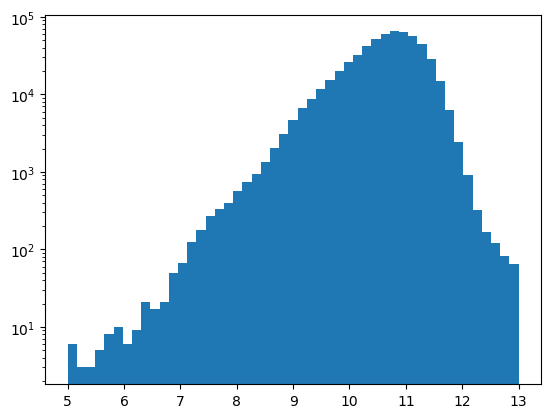

In [129]:

plt.hist(mstar_vals,bins=np.linspace(5,13,50))
plt.yscale("log")
plt.show()


In [130]:
dwarf_mask = (mstar_vals<9.25) & (mstar_vals> 6) & (gr_col > -0.5)

In [131]:
nsa_dwarf_tab = {"RA":ra_f[dwarf_mask], 
                "DEC": dec_f[dwarf_mask], 
                "Z": zred_f[dwarf_mask], 
                "MSTAR": mstar_vals[dwarf_mask], 
                "MAG_R": rmag_f[dwarf_mask],
                "gr_col": gr_col[dwarf_mask],
                }

nsa_dwarf_tab = Table(nsa_dwarf_tab)

In [156]:
print("6 < Mstar < 7 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 7) & (nsa_dwarf_tab["MSTAR"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 8) & (nsa_dwarf_tab["MSTAR"] > 7)))
print("8 < Mstar < 9.25 Counts =", np.sum((nsa_dwarf_tab["MSTAR"] < 9.25) & (nsa_dwarf_tab["MSTAR"] > 8)))

6 < Mstar < 7 Counts = 131
7 < Mstar < 8 Counts = 1517
8 < Mstar < 9.25 Counts = 19717


In [134]:
19717+1517+131

21365

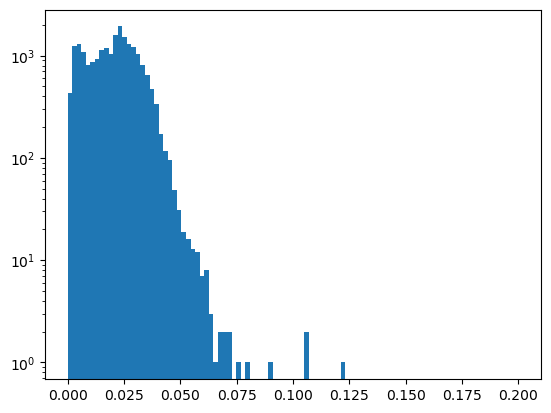

In [135]:
plt.hist(nsa_dwarf_tab["Z"],bins=np.linspace(0,0.2,100))
plt.yscale("log")
plt.show()

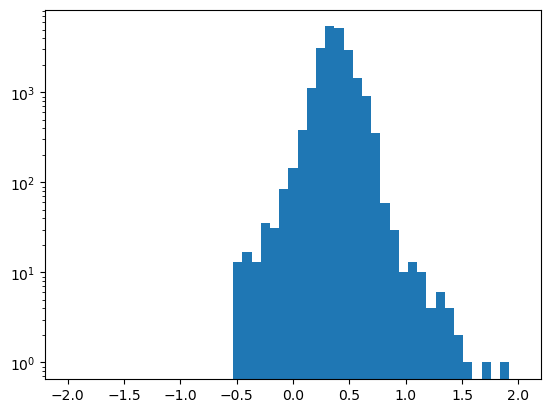

In [136]:
plt.hist(nsa_dwarf_tab["gr_col"],bins=np.linspace(-2,2,50))
plt.yscale("log")
plt.show()

In [137]:
## there is this whole junk population of gr < -0.5 gaalxies.

In [139]:
## SAVE THIS CATALOG

nsa_dwarf_tab.write("/pscratch/sd/v/virajvm/catalog/nsa_dwarf_catalog.fits",overwrite=True)

# SAGA+SAGAbg dwarf counts

In [141]:
from astropy.table import Table
saga_gals = Table.read('https://sagasurvey.org/data/saga-dr3-tableC2.txt', format='ascii.mrt')
print(len(saga_gals))

75704


In [142]:
print(np.sum( (saga_gals["log(M*)"] < 9.25) & (saga_gals["log(M*)"] > 6) )  )

10263


In [143]:
rmags_saga = saga_gals["rmag"].data
gmags_saga = saga_gals["gr"].data + saga_gals["rmag"].data
zreds_saga = saga_gals["z"].data

In [144]:
mstar_saga = get_stellar_mass_mia(saga_gals["gr"].data, gmags_saga, zreds_saga)

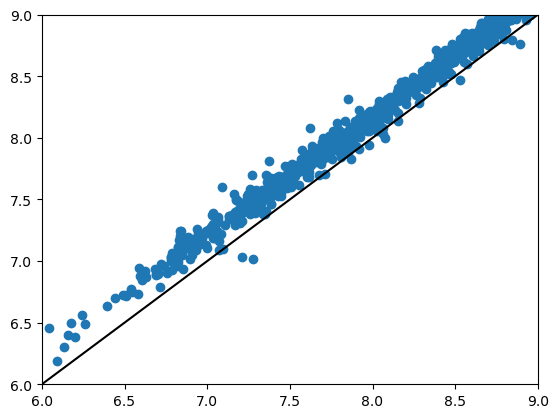

In [145]:
plt.scatter(saga_gals["log(M*)"].data, mstar_saga)
plt.xlim([6,9])
plt.ylim([6,9])
plt.plot([6,9],[6,9],color="k")
plt.show()

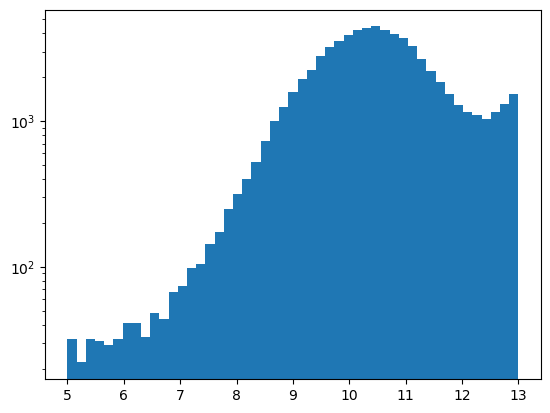

In [146]:

plt.hist(mstar_saga,bins=np.linspace(5,13,50))
plt.yscale("log")
plt.show()


In [147]:
print(np.sum( (mstar_saga < 9.25) & (mstar_saga > 6) )  )

saga_dwarf_mask = (mstar_saga < 9.25) & (mstar_saga > 6)

8954


In [149]:
saga_gals["MSTAR"] = mstar_saga

In [150]:
saga_dwarf_gals = saga_gals[saga_dwarf_mask]

In [152]:
saga_dwarf_gals.write("/pscratch/sd/v/virajvm/catalog/saga_dr3_dwarf_cat.fits",overwrite=True)

In [153]:
len(saga_dwarf_gals)

8954

In [154]:
print("6 < Mstar < 7 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 7) & (saga_dwarf_gals["MSTAR"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 8) & (saga_dwarf_gals["MSTAR"] > 7)))
print("8 < Mstar < 9.25 Counts =", np.sum((saga_dwarf_gals["MSTAR"] < 9.25) & (saga_dwarf_gals["MSTAR"] > 8)))

6 < Mstar < 7 Counts = 284
7 < Mstar < 8 Counts = 945
8 < Mstar < 9.25 Counts = 7725


In [155]:
284+945+7725

8954